In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7

# 7 класів (типово для FER2013)
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

train_dir = r"train"
val_dir   = r"test"

In [3]:
# 1) Завантаження даних з директорій
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,   # фіксуємо порядок класів
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [4]:
# 2) Передоброблення за статтею: resize вже зроблено, тепер нормалізація /255
# + важливий практичний момент: якщо у вас grayscale, треба перетворити на 3 канали
def to_rgb_and_normalize(images, labels):
    images = tf.cast(images, tf.float32)

    # Якщо канал 1 (інколи датасети так збережені), зробимо RGB через повторення каналу
    # Якщо вже RGB — залишиться як є.
    if images.shape.rank == 4 and images.shape[-1] == 1:
        images = tf.image.grayscale_to_rgb(images)

    images = images / 255.0  # як описано в статті
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(to_rgb_and_normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(to_rgb_and_normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [5]:
# 3) MobileNetV2 backbone (transfer learning)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # спочатку "заморожуємо" як typical TL


In [6]:
# 4) "Голова" класифікатора: Dense -> ReLU -> Dense -> ReLU -> Softmax(7)
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256)(x)
x = layers.ReLU()(x)

x = layers.Dense(128)(x)
x = layers.ReLU()(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# 5) Навчання (додайте callbacks за потреби)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 542s 598ms/step - accuracy: 0.3557 - loss: 1.6437 - val_accuracy: 0.4610 - val_loss: 1.4111 - learning_rate: 1.0000e-04
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 525s 585ms/step - accuracy: 0.4730 - loss: 1.3881 - val_accuracy: 0.4805 - val_loss: 1.3571 - learning_rate: 1.0000e-04
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 523s 583ms/step - accuracy: 0.5131 - loss: 1.3065 - val_accuracy: 0.4985 - val_loss: 1.3239 - learning_rate: 1.0000e-04
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 525s 585ms/step - accuracy: 0.5339 - loss: 1.2465 - val_accuracy: 0.5033 - val_loss: 1.3095 - learning_rate: 1.0000e-04
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 524s 584ms/step - accuracy: 0.5535 - loss: 1.2007 - val_accuracy: 0.5008 - val_loss: 1.3007 - learning_rate: 1.0000e-04
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 523s 583ms/step - accuracy: 0.5720 - loss: 1.1566 - val_accuracy: 0.5160 - val_loss: 1.2803 - learning_rate: 1.0000e-04
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
# 6) (Опційно) Fine-tuning: розморозити верхні шари backbone і донавчити з меншим LR
base_model.trainable = True

# Наприклад, заморозимо нижні ~100 шарів, а верхні донавчимо
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

model.save("mobilenetv2_7class.h5")

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 853s 937ms/step - accuracy: 0.3551 - loss: 1.8637 - val_accuracy: 0.4766 - val_loss: 1.4708 - learning_rate: 1.0000e-05
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 855s 953ms/step - accuracy: 0.5106 - loss: 1.2980 - val_accuracy: 0.5088 - val_loss: 1.3307 - learning_rate: 1.0000e-05
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 862s 960ms/step - accuracy: 0.5792 - loss: 1.1407 - val_accuracy: 0.5371 - val_loss: 1.2524 - learning_rate: 1.0000e-05
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 849s 945ms/step - accuracy: 0.6205 - loss: 1.0242 - val_accuracy: 0.5591 - val_loss: 1.2148 - learning_rate: 1.0000e-05
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 847s 943ms/step - accuracy: 0.6638 - loss: 0.9207 - val_accuracy: 0.5683 - val_loss: 1.2072 - learning_rate: 1.0000e-05
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 846s 942ms/step - accuracy: 0.7004 - loss: 0.8227 - val_accuracy: 0.5708 - val_loss: 1.2182 - learning_rate: 1.0000e-05
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 

225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 483ms/step
Validation Accuracy after Fine-Tuning: 0.5794093062134299

Classification Report after Fine-Tuning:

              precision    recall  f1-score   support

       angry     0.4861    0.4562    0.4707       958
     disgust     0.8205    0.2883    0.4267       111
        fear     0.4584    0.3984    0.4263      1024
       happy     0.7656    0.7954    0.7802      1774
         sad     0.4502    0.4779    0.4636      1247
    surprise     0.7194    0.7064    0.7128       831
     neutral     0.5033    0.5580    0.5292      1233

    accuracy                         0.5794      7178
   macro avg     0.6005    0.5258    0.5442      7178
weighted avg     0.5801    0.5794    0.5770      7178



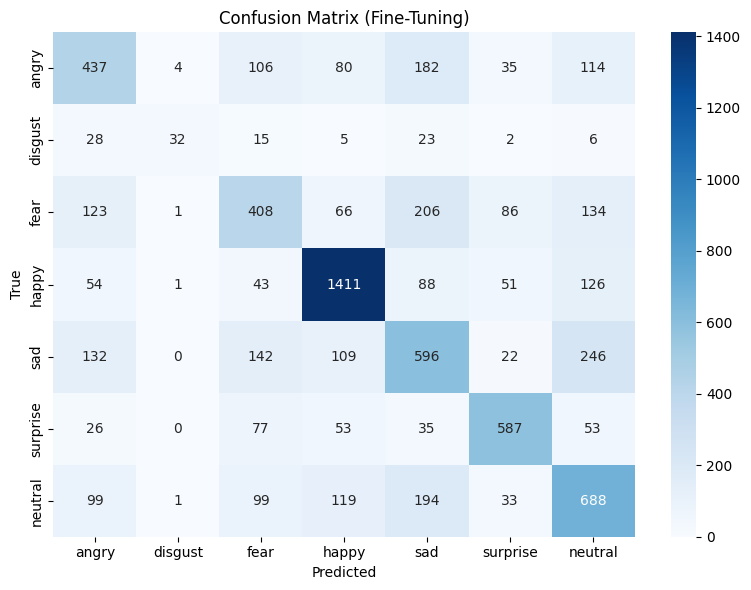

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# === Прогнози
y_prob = model.predict(val_ds)
y_pred = np.argmax(y_prob, axis=1)

# === Істинні мітки
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)

# === Accuracy
val_acc = accuracy_score(y_true, y_pred)
print("Validation Accuracy after Fine-Tuning:", val_acc)

# === Classification Report
print("\nClassification Report after Fine-Tuning:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# === Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Fine-Tuning)")
plt.tight_layout()
plt.show()

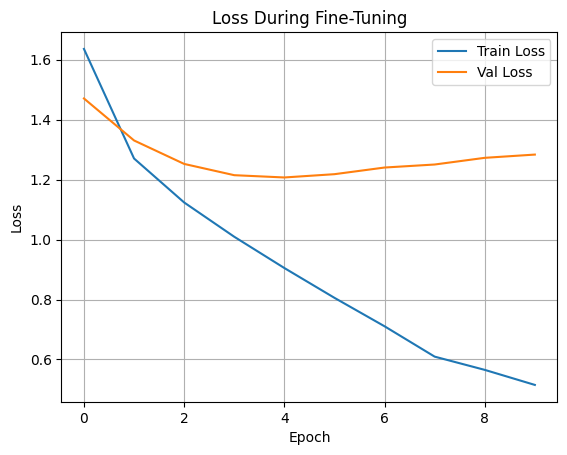

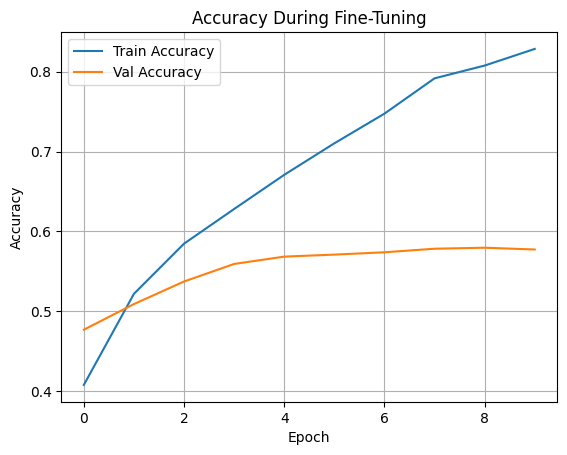

In [12]:
# === Loss Plot
plt.figure()
plt.plot(fine_history.history['loss'], label='Train Loss')
plt.plot(fine_history.history['val_loss'], label='Val Loss')
plt.title('Loss During Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# === Accuracy Plot
plt.figure()
plt.plot(fine_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy During Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
